In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from scipy.optimize import curve_fit

In [ ]:
# === Configuration ===
data_root = Path("data")  # adjust to where your results live
output_root = Path("combined_results")
output_root.mkdir(exist_ok=True, parents=True)

# Known parameter arrays
FLEX_STRENGTH_values = [0.500]

start = 0.08
end = 0.4
n = 500
step = (end - start) / (n - 1)
S_values = [start + i * step for i in range(n)]

S_values = np.arange(0.08, 0.40, step=0.01)


# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.2g}"
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv(output_root / "summary_s-phase_final2.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations: 100%|████████████████████████████████████████| 32/32 [00:02<00:00, 11.08it/s]


✅ Combined 32 parameter groups
📁 Results saved in: C:\Users\audso\OneDrive\Dokumenter\GitHub\DHT-simulations-misinformation-propagation\old_S_phase\combined_results


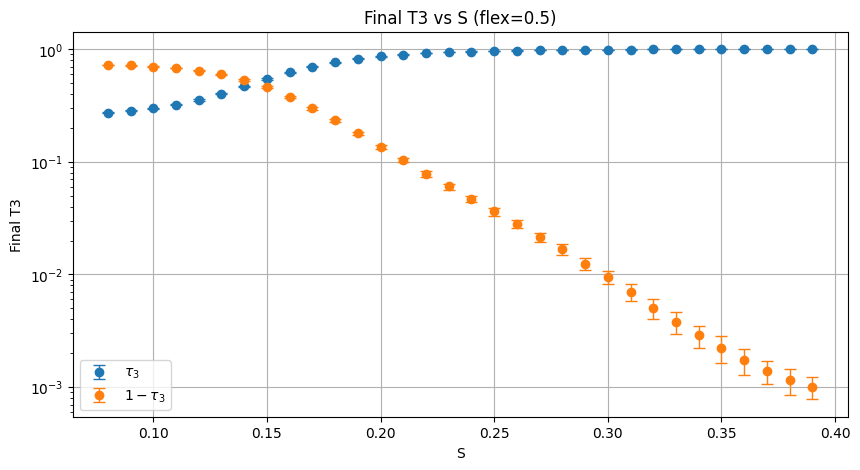

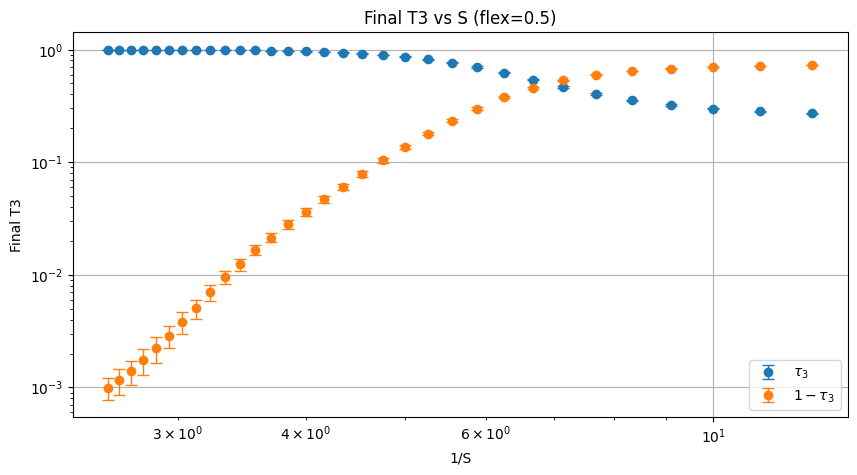

In [47]:
# Load your final summary (update path if needed)
df = pd.read_csv("combined_results/summary_s-phase_final2.csv")

# Filter for flex = 0.5
flex_val = 0.5
df_flex = df[df['F'] == flex_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("S")

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("S")
# plt.xlim((0.01, 1))
plt.semilogy()
# plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("1/S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.semilogx()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

Tail exponent γ = 0.8630733780373767


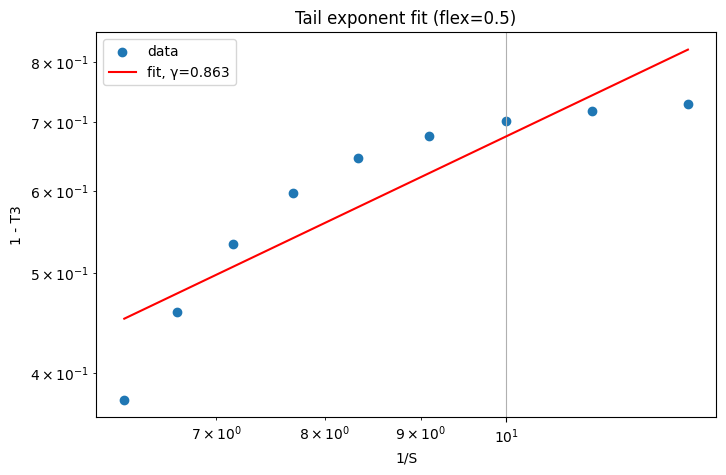

In [44]:
Sc=0.16
tail = df[df["S"] < Sc]
mask = df_flex["S"] < Sc
Sfit = df_flex["S"][mask]
X = np.log(Sc - Sfit)
Y = np.log(df_flex["T3_std"][mask]**2)
gamma = - np.polyfit(X, Y, 1)[0]
S_tail = tail["S"].values
T3_tail = tail["T3"].values
one_minus_T3 = 1 - T3_tail

# --- log-log fit of tail ---
x = np.log(1 / S_tail)
y = np.log(one_minus_T3)

coef = np.polyfit(x, y, 1)
gamma = coef[0]
intercept = coef[1]

# --- predicted line ---
xfit = np.linspace(min(x), max(x), 200)
yfit = gamma * xfit + intercept

print("Tail exponent γ =", gamma)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.scatter(1/S_tail, one_minus_T3, label="data")
plt.plot(np.exp(xfit), np.exp(yfit), 'r-', label=f"fit, γ={gamma:.3f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("1/S")
plt.ylabel("1 - T3")
plt.title("Tail exponent fit (flex=0.5)")
plt.grid(True)
plt.legend()
plt.show()

The peak of $\nabla\tau_3(S)$ is at S = 0.1599999999999999


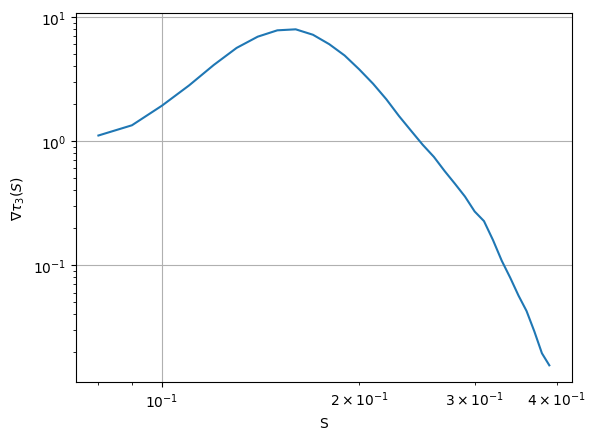

In [46]:
dT3 = np.gradient(df_flex[metric], df_flex["S"])
print(fr"The peak of $\nabla\tau_3(S)$ is at S = {df_flex['S'][np.argmax(dT3)]}")
plt.plot(df_flex["S"], np.abs(dT3))
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xlabel("S")
plt.ylabel(fr"$\nabla\tau_3(S)$")
plt.show()

Critical S  = 0.159522
Sharpness a = 39.488862
Tlow        = 0.231644
Thigh       = 0.993094
R²          = 0.999467


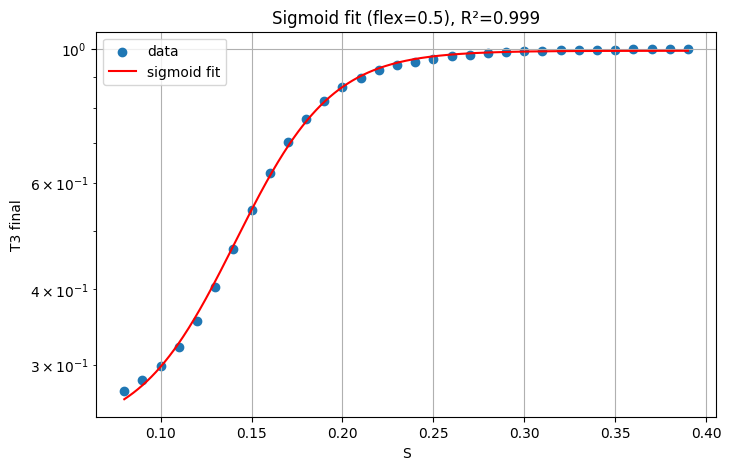

In [49]:
def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T, label="data")
plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit")
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("S")
plt.ylabel("T3 final")
plt.title(f"Sigmoid fit (flex=0.5), R²={R2:.3f}")
plt.legend()
plt.grid(True)
plt.show()



Critical exponent β = 0.08987704593713437
Critical exponent alpha = 6.250000000039063


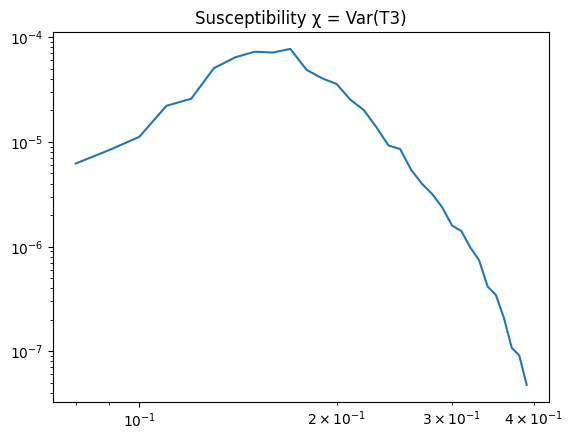

In [48]:
mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]

logS = np.log(Sfit - Sc)
logT = np.log(Tfit)

coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.159999999999)

plt.plot(df_flex["S"], df_flex["T3_std"]**2)
plt.xscale("log")
plt.yscale("log")
plt.title("Susceptibility χ = Var(T3)")
plt.show()

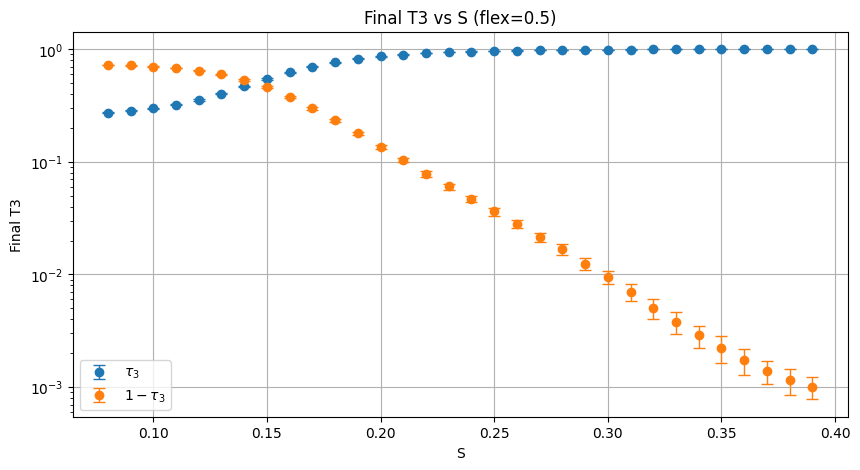

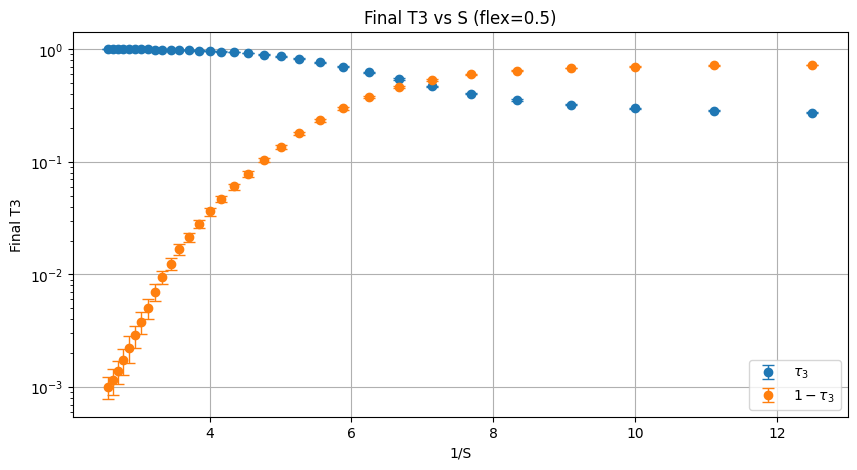

The peak of $\nabla\tau_3(S)$ is at S = 0.1599999999999999


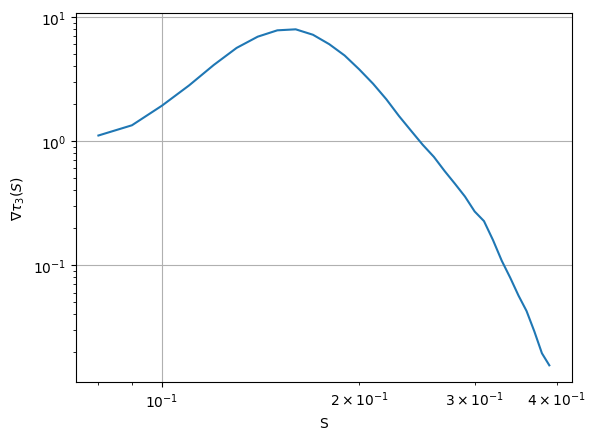

Critical S  = 0.159522
Sharpness a = 39.488862
Tlow        = 0.231644
Thigh       = 0.993094
R²          = 0.999467


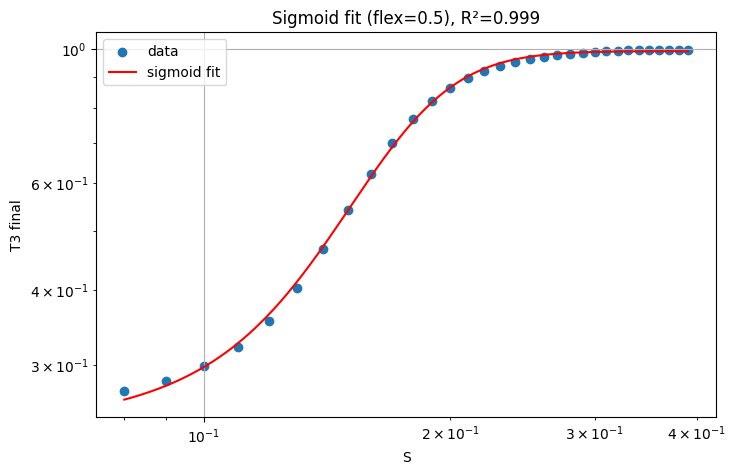

Critical exponent β = 0.08987704593713437
Critical exponent alpha = 6.250000000039063


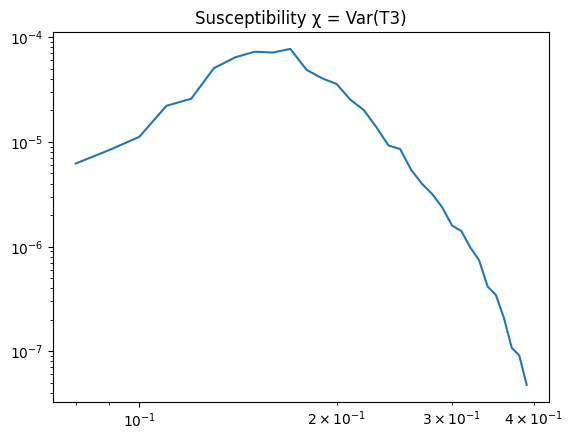

In [ ]:
# Load your final summary (update path if needed)
df = pd.read_csv("combined_results/summary_s-phase_final2.csv")

# Filter for flex = 0.5
flex_val = 0.5
df_flex = df[df['F'] == flex_val].copy()

# Sort by S for a clean plot
df_flex = df_flex.sort_values("S")

# Choose final truthfulness metric: T0, T1, T2, T3
metric = "T3"
std = metric + "_std"

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plt.scatter(df_flex["S"], df_flex[metric], marker="o")
plt.errorbar(1/df_flex["S"], df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$\tau_3$")
plt.errorbar(1/df_flex["S"], 1-df_flex[metric], df_flex[std], fmt='o', capsize=4, elinewidth=1, label=r"$1-\tau_3$")
plt.xlabel("1/S")
# plt.xlim((0.01, 1))
plt.semilogy()
plt.ylabel(f"Final {metric}")
plt.title(f"Final {metric} vs S (flex={flex_val})")
plt.grid(True)
plt.legend()
plt.show()

dT3 = np.gradient(df_flex[metric], df_flex["S"])
print(fr"The peak of $\nabla\tau_3(S)$ is at S = {df_flex['S'][np.argmax(dT3)]}")
plt.plot(df_flex["S"], np.abs(dT3))
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xlabel("S")
plt.ylabel(fr"$\nabla\tau_3(S)$")
plt.show()

def sigmoid(S, a, Sc, Tlow, Thigh):
    return Tlow + (Thigh - Tlow) / (1 + np.exp(-a*(S - Sc)))

S = df_flex["S"].values
T = df_flex[metric].values

p0 = [50, 0.3, min(T), max(T)]

# Fit
params, cov = curve_fit(sigmoid, S, T, p0=p0, maxfev=50000)
a, Sc, Tlow, Thigh = params

# Predictions
T_pred = sigmoid(S, *params)

# R² calculation
SS_res = np.sum((T - T_pred)**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2 = 1 - SS_res / SS_tot

print(f"Critical S  = {Sc:.6f}")
print(f"Sharpness a = {a:.6f}")
print(f"Tlow        = {Tlow:.6f}")
print(f"Thigh       = {Thigh:.6f}")
print(f"R²          = {R2:.6f}")

S_sorted = np.linspace(min(S), max(S), 500)
T_fit_curve = sigmoid(S_sorted, *params)

plt.figure(figsize=(8,5))
plt.scatter(S, T, label="data")
plt.plot(S_sorted, T_fit_curve, 'r-', label="sigmoid fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("S")
plt.ylabel("T3 final")
plt.title(f"Sigmoid fit (flex=0.5), R²={R2:.3f}")
plt.legend()
plt.grid(True)
plt.show()

mask = df_flex["S"] > Sc  # one side of transition
Sfit = df_flex["S"][mask]
Tfit = df_flex[metric][mask]

logS = np.log(Sfit - Sc)
logT = np.log(Tfit)

coef = np.polyfit(logS, logT, 1)
beta = coef[0]
print("Critical exponent β =", beta)
print("Critical exponent alpha =", 1/0.159999999999)

plt.plot(df_flex["S"], df_flex["T3_std"]**2)
plt.xscale("log")
plt.yscale("log")
plt.title("Susceptibility χ = Var(T3)")
plt.show()

C:\Users\audso\AppData\Local\Temp\ipykernel_23984\3381247423.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1000x670 with 0 Axes>

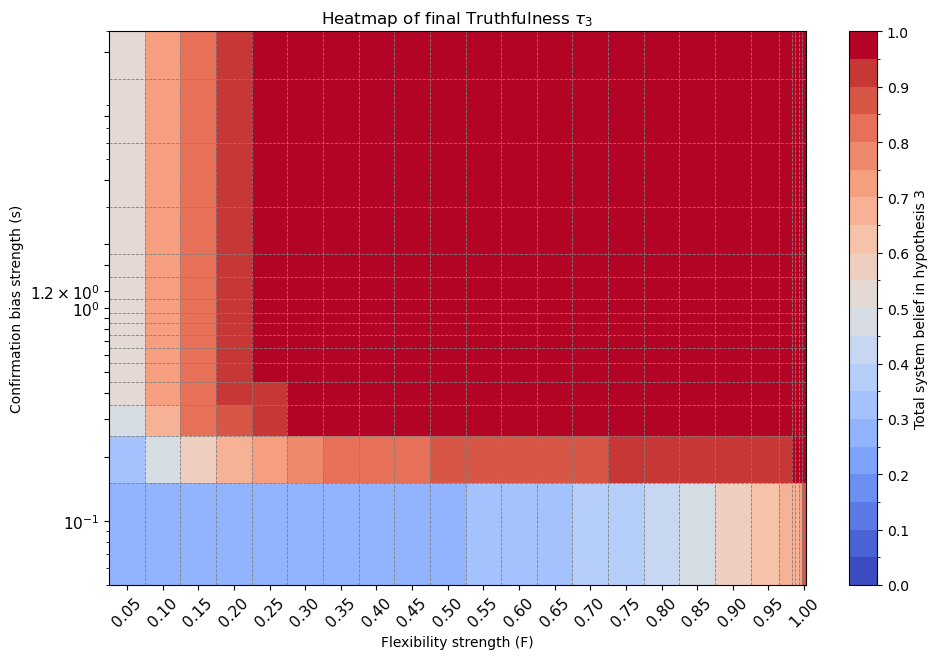

<Figure size 1000x670 with 0 Axes>

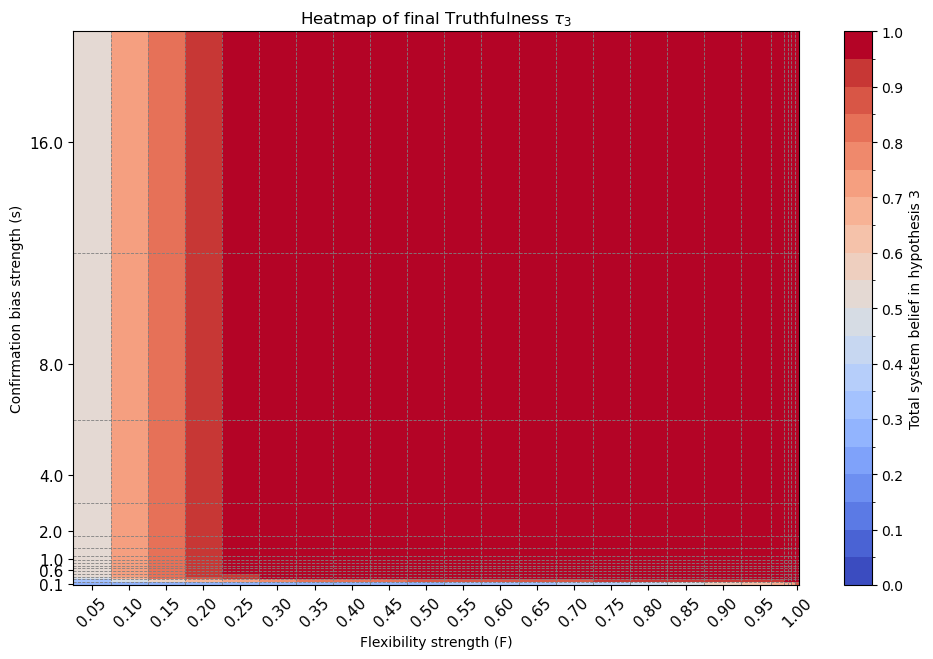

✅ Saved heatmap to plots\heatmap_T3.png


In [7]:
data_path = Path("combined_results/summary_ba_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")

ax.set_yscale('log')
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap__logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
plt.yticks(y_ticks, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved heatmap to {out_path}")

Processing combined files: 100%|██████████| 384/384 [00:08<00:00, 47.18it/s]
C:\Users\audso\AppData\Local\Temp\ipykernel_33648\3342389618.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


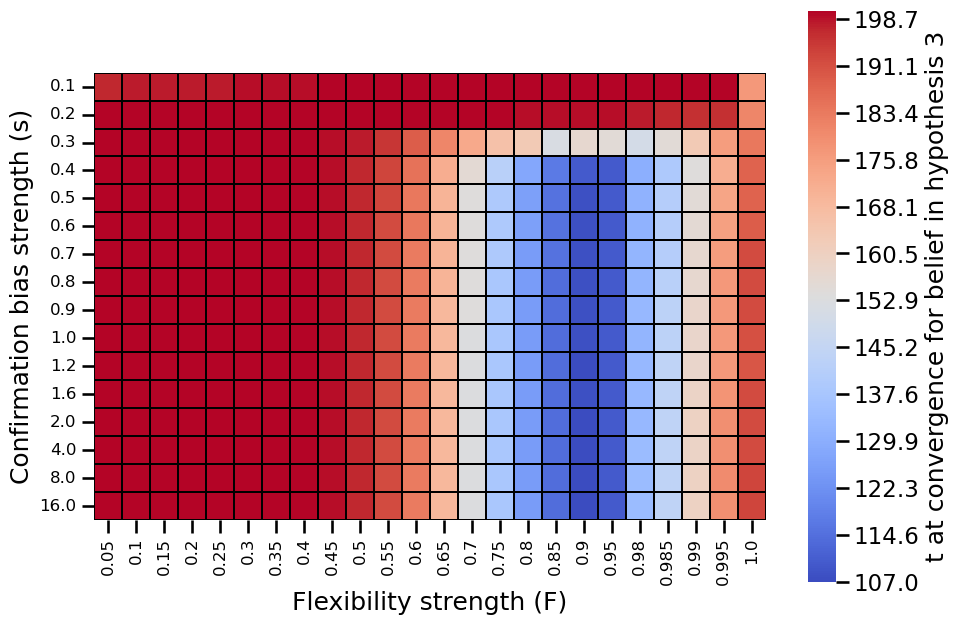

✅ Saved convergence heatmap to plots\convergence_heatmap_T3.png


In [4]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-4       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 200
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# === Plot ===
plt.figure(figsize=(10, 6.7))
sns.set_context("talk")

ax = sns.heatmap(
    pivot,
    cmap="coolwarm",
    vmin=np.min(df["converged_at"]),
    vmax=np.max(df["converged_at"]),
    # norm=norm,
    cbar_kws={
        "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
        "label": f"t at convergence for belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"convergence_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()


print(f"✅ Saved convergence heatmap to {out_path}")
